In [1]:
!pip install -q pandas matplotlib scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
os.makedirs("../outputs/tables", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/predictions", exist_ok=True)

In [4]:
sarcasm_df = pd.read_csv("../outputs/data/sarcasm.csv")

print("Data shape:", sarcasm_df.shape)
sarcasm_df.head()

Data shape: (12641, 9)


,text,label,variety,source,task,split,text_length,word_count,clean_text
0,"Located 2 blocks back from The Strand, ideal f...",0,en-AU,Google,Sarcasm,train,281,48,"located 2 blocks back from the strand, ideal f..."
1,Have n't been to AJ in a few years so popped i...,0,en-AU,Google,Sarcasm,train,368,75,have n't been to aj in a few years so popped i...
2,Tried their folded chili eggs() plus mushrooms...,0,en-AU,Google,Sarcasm,train,510,93,tried their folded chili eggs() plus mushrooms...
3,Thanks for the vegan options. Minus one star f...,0,en-AU,Google,Sarcasm,train,108,17,thanks for the vegan options. minus one star f...
4,Bought an ANGUS Bacon BBQ Sauce with Onion and...,0,en-AU,Google,Sarcasm,train,193,38,bought an angus bacon bbq sauce with onion and...


In [5]:
print(sarcasm_df.columns)

Index(['text', 'label', 'variety', 'source', 'task', 'split', 'text_length',
       'word_count', 'clean_text'],
      dtype='str')


In [6]:
print("Label distribution:")
print(sarcasm_df["label"].value_counts().sort_index())

Label distribution:
label
0    10827
1     1814
Name: count, dtype: int64


In [7]:
print("Split distribution:")
print(sarcasm_df["split"].value_counts())

Split distribution:
split
train         8894
test          2531
validation    1216
Name: count, dtype: int64


In [8]:
train_df = sarcasm_df[sarcasm_df["split"] == "train"].copy()
valid_df = sarcasm_df[sarcasm_df["split"] == "validation"].copy()
test_df = sarcasm_df[sarcasm_df["split"] == "test"].copy()

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

Train: (8894, 9)
Validation: (1216, 9)
Test: (2531, 9)


In [9]:
X_train = train_df["clean_text"]
y_train = train_df["label"]

X_valid = valid_df["clean_text"]
y_valid = valid_df["label"]

X_test = test_df["clean_text"]
y_test = test_df["label"]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_valid))
print("Testing samples:", len(X_test))

Training samples: 8894
Validation samples: 1216
Testing samples: 2531


In [10]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_valid_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (8894, 20000)
Validation TF-IDF shape: (1216, 20000)
Test TF-IDF shape: (2531, 20000)


In [11]:
majority_model = DummyClassifier(strategy="most_frequent")

majority_model.fit(X_train_tfidf, y_train)

majority_pred = majority_model.predict(X_test_tfidf)

In [12]:
majority_accuracy = accuracy_score(y_test, majority_pred)
majority_f1 = f1_score(y_test, majority_pred, average="macro")
majority_precision = precision_score(y_test, majority_pred, average="macro", zero_division=0)
majority_recall = recall_score(y_test, majority_pred, average="macro", zero_division=0)

print("Majority Class Baseline")
print("-----------------------")
print("Accuracy:", majority_accuracy)
print("Macro F1:", majority_f1)
print("Macro Precision:", majority_precision)
print("Macro Recall:", majority_recall)

print("\nClassification Report:")
print(classification_report(y_test, majority_pred, zero_division=0))

Majority Class Baseline
-----------------------
Accuracy: 0.8557882259976294
Macro F1: 0.4611454119650841
Macro Precision: 0.4278941129988147
Macro Recall: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      2166
           1       0.00      0.00      0.00       365

    accuracy                           0.86      2531
   macro avg       0.43      0.50      0.46      2531
weighted avg       0.73      0.86      0.79      2531



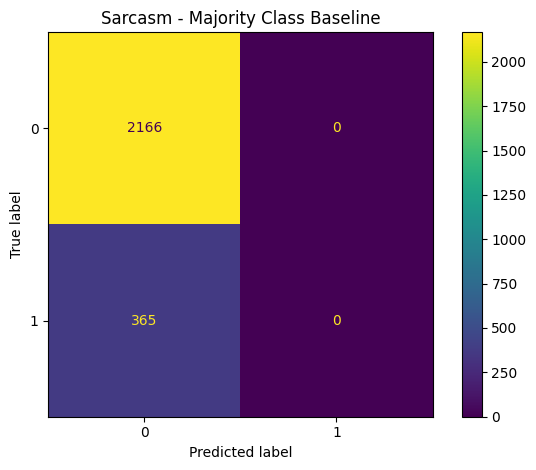

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, majority_pred)

plt.title("Sarcasm - Majority Class Baseline")
plt.tight_layout()
plt.savefig("../outputs/figures/sarcasm_majority_confusion_matrix.png", dpi=300)
plt.show()

In [17]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_tfidf, y_train)

logistic_pred = logistic_model.predict(X_test_tfidf)

In [18]:
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_f1 = f1_score(y_test, logistic_pred, average="macro")
logistic_precision = precision_score(y_test, logistic_pred, average="macro", zero_division=0)
logistic_recall = recall_score(y_test, logistic_pred, average="macro", zero_division=0)

print("TF-IDF + Logistic Regression")
print("----------------------------")
print("Accuracy:", logistic_accuracy)
print("Macro F1:", logistic_f1)
print("Macro Precision:", logistic_precision)
print("Macro Recall:", logistic_recall)

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred, zero_division=0))

TF-IDF + Logistic Regression
----------------------------
Accuracy: 0.8549980244962465
Macro F1: 0.46627337661554125
Macro Precision: 0.5947854785478548
Macro Recall: 0.5018163649932329

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      2166
           1       0.33      0.01      0.01       365

    accuracy                           0.85      2531
   macro avg       0.59      0.50      0.47      2531
weighted avg       0.78      0.85      0.79      2531



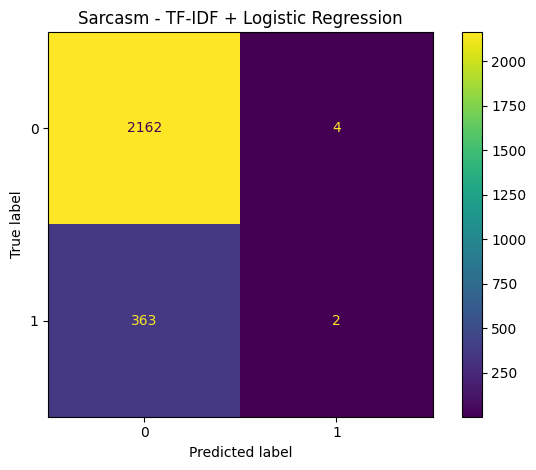

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, logistic_pred)

plt.title("Sarcasm - TF-IDF + Logistic Regression")
plt.tight_layout()
plt.savefig("../outputs/figures/sarcasm_logistic_confusion_matrix.png", dpi=300)
plt.show()

In [20]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

In [21]:
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred, average="macro")
svm_precision = precision_score(y_test, svm_pred, average="macro", zero_division=0)
svm_recall = recall_score(y_test, svm_pred, average="macro", zero_division=0)

print("TF-IDF + Linear SVM")
print("-------------------")
print("Accuracy:", svm_accuracy)
print("Macro F1:", svm_f1)
print("Macro Precision:", svm_precision)
print("Macro Recall:", svm_recall)

print("\nClassification Report:")
print(classification_report(y_test, svm_pred, zero_division=0))

TF-IDF + Linear SVM
-------------------
Accuracy: 0.847096009482418
Macro F1: 0.5802701962644576
Macro Precision: 0.6494723321727098
Macro Recall: 0.5666799478870211

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2166
           1       0.43      0.17      0.25       365

    accuracy                           0.85      2531
   macro avg       0.65      0.57      0.58      2531
weighted avg       0.81      0.85      0.82      2531



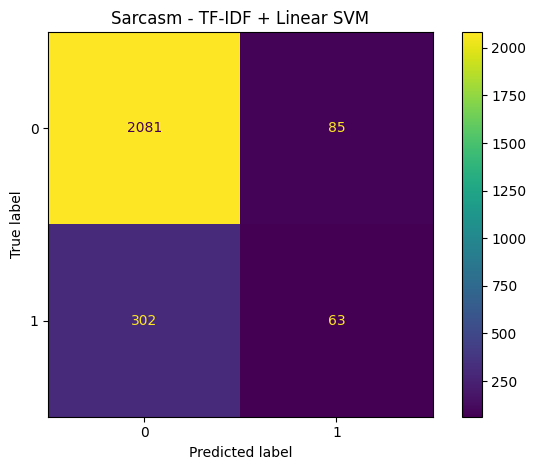

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)

plt.title("Sarcasm - TF-IDF + Linear SVM")
plt.tight_layout()
plt.savefig("../outputs/figures/sarcasm_svm_confusion_matrix.png", dpi=300)
plt.show()

In [24]:
results = [
    {
        "task": "Sarcasm",
        "model": "Majority Class",
        "accuracy": majority_accuracy,
        "macro_f1": majority_f1,
        "macro_precision": majority_precision,
        "macro_recall": majority_recall
    },
    {
        "task": "Sarcasm",
        "model": "TF-IDF + Logistic Regression",
        "accuracy": logistic_accuracy,
        "macro_f1": logistic_f1,
        "macro_precision": logistic_precision,
        "macro_recall": logistic_recall
    },
    {
        "task": "Sarcasm",
        "model": "TF-IDF + Linear SVM",
        "accuracy": svm_accuracy,
        "macro_f1": svm_f1,
        "macro_precision": svm_precision,
        "macro_recall": svm_recall
    }
]

results_df = pd.DataFrame(results)

results_df

,task,model,accuracy,macro_f1,macro_precision,macro_recall
0,Sarcasm,Majority Class,0.855788,0.461145,0.427894,0.500000
1,Sarcasm,TF-IDF + Logistic Regression,0.854998,0.466273,0.594785,0.501816
2,Sarcasm,TF-IDF + Linear SVM,0.847096,0.580270,0.649472,0.566680


In [ ]:
results_df.to_csv("../outputs/tables/sarcasm_baseline_results.csv", index=False)

print("Saved sarcasm baseline results.")

Sentiment Baseline Summary


,task,model,accuracy,macro_f1,macro_precision,macro_recall
0,Sentiment,Majority Class,0.503765,0.335003,0.251883,0.500000
1,Sentiment,TF-IDF + Logistic Regression,0.829964,0.829424,0.833245,0.829588
2,Sentiment,TF-IDF + Linear SVM,0.820848,0.820743,0.821230,0.820713



Best baseline model:
TF-IDF + Logistic Regression

Best Macro-F1:
0.829423996885916
